# Cat Detection using YOLOv8s

### Objective
The objective of this project is to develop a deep learning based object detection model capable of detecting cats in images using the YOLOv8 architecture.
The trained model identifies cats, generates bounding boxes around detected objects, and provides confidence scores for each prediction.

### Technologies Used
- Python
- PyTorch
- YOLOv8s (Ultralytics)
- OpenCV
- Google Colab (Tesla T4 GPU)

## Environment Setup

In [2]:
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


## Dataset Extraction and Preparation

In [31]:
import zipfile

zip_ref = zipfile.ZipFile('/content/cat_dataset.zip', 'r')
zip_ref.extractall('/content/dataset')
zip_ref.close()

## Dataset Verification

In [6]:
import os

os.listdir('/content/dataset')

['data.yaml',
 'train',
 'README.roboflow.txt',
 'valid',
 'test',
 'README.dataset.txt']

## Data Visualization

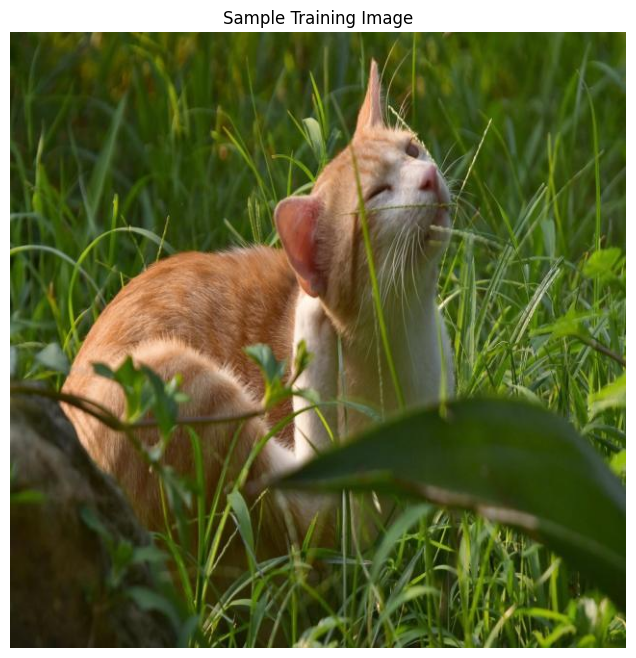

In [7]:
import cv2
import matplotlib.pyplot as plt
import glob

image_path = glob.glob('/content/dataset/train/images/*.jpg')[0]

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title("Sample Training Image")
plt.show()

## Model Initialization
#### The YOLOv8s pretrained model is loaded using transfer learning.

In [8]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Model Training
The model is trained on the custom cat detection dataset using YOLOv8s.

## Training Configuration
- Epochs: 100
- Image Size: 640
- Batch Size: 8
- Optimizer: SGD

## Data Augmentation Techniques
The following augmentation techniques were applied to improve model generalization:
- Horizontal flipping
- Mild rotation
- Translation
- Scaling
- HSV color augmentation
- Mosaic augmentation


In [9]:
results = model.train(

    data='/content/dataset/data.yaml',

    # Training
    epochs=100,
    imgsz=640,
    batch=8,
    device=0,

    # Optimizer
    optimizer='SGD',
    lr0=0.001,

    # Early stopping
    patience=30,

    # LIGHT AUGMENTATION
    degrees=5.0,
    translate=0.05,
    scale=0.1,

    fliplr=0.5,
    flipud=0.0,

    hsv_h=0.01,
    hsv_s=0.3,
    hsv_v=0.2,

    mosaic=0.5,
    mixup=0.0,

    # Validation
    val=True,
    save=True
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=30, perspec

## Model Evaluation

The trained model is evaluated using standard object detection metrics:

- Precision
- Recall
- mAP50
- mAP50-95

In [10]:
metrics = model.val()

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1468.9±325.8 MB/s, size: 55.5 KB)
val: Scanning /content/dataset/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 20.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.5s
                   all         43         50      0.737       0.74      0.792      0.456
Speed: 14.9ms preprocess, 14.7ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/runs/detect/val


## Inference on Test Images

The trained model is tested on unseen images from the test dataset.

In [11]:
results = model.predict(
    source='/content/dataset/test/images',
    save=True,
    conf=0.25
)


image 1/18 /content/dataset/test/images/0066-J3l4Zf33nfc_jpg.rf.29cf8bb11494237408203b179fbc2e30.jpg: 640x640 1 Cats, 16.1ms
image 2/18 /content/dataset/test/images/0262-jo9XwI6B8Rs_jpg.rf.0dfad9458ae98a798c411706ec0d4818.jpg: 640x640 1 Cats, 16.1ms
image 3/18 /content/dataset/test/images/0340-LfHN48aCVtE_jpg.rf.b29d11a34cd60ddb9ccd4e5942ce7425.jpg: 640x640 1 Cats, 16.1ms
image 4/18 /content/dataset/test/images/0366-6B-WeK_fT8M_jpg.rf.a2c564572c501418b8384f52f8b2dbf3.jpg: 640x640 1 Cats, 16.1ms
image 5/18 /content/dataset/test/images/0502-xxdTZFljIfw_jpg.rf.408cc1f5131c04170e06126fd6c94337.jpg: 640x640 1 Cats, 16.1ms
image 6/18 /content/dataset/test/images/1101-WMH1xzEznuY_jpg.rf.6afdc30101bc2166c923ead59c30c8c8.jpg: 640x640 1 Cats, 13.7ms
image 7/18 /content/dataset/test/images/1377-QvqfyLHM6GM_jpg.rf.e5a0cbbb84d902298c63f2063e71b8b3.jpg: 640x640 1 Cats, 13.8ms
image 8/18 /content/dataset/test/images/1501-22bl-hths7o_jpg.rf.fe41675d0dc955d02ca0addf08897841.jpg: 640x640 (no detections

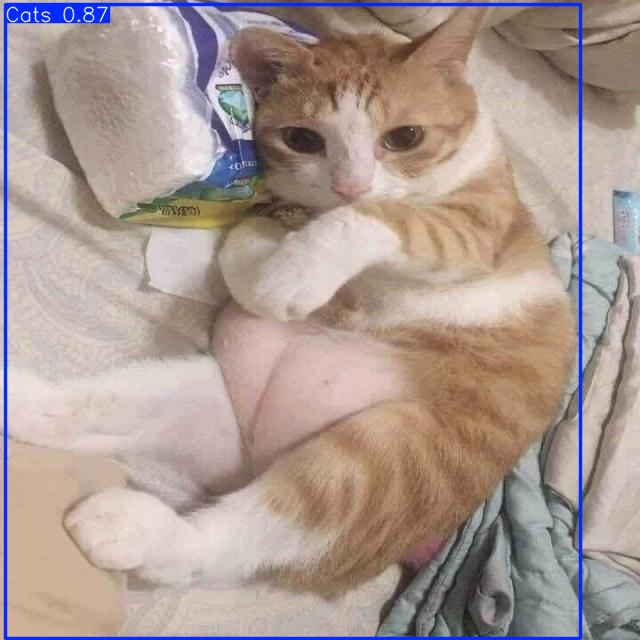

In [12]:
from IPython.display import Image, display
import glob

predicted_images = glob.glob('/content/runs/detect/predict/*.jpg')

display(Image(filename=predicted_images[0]))

## Inference on Custom Images

#### Testing on Non-Cat Images

Additional experiments were performed using images containing:
- humans
- dogs

In [21]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train/weights/best.pt')

In [22]:
results = model.predict(
    source='/content/3.jpg',
    conf=0.5,
    save=True
)


image 1/1 /content/3.jpg: 480x640 (no detections), 48.7ms
Speed: 2.1ms preprocess, 48.7ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-3


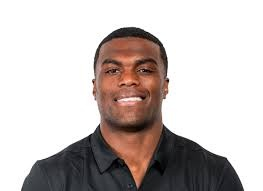

In [23]:
from IPython.display import Image, display

display(Image(filename='/content/runs/detect/predict-3/3.jpg'))

In [27]:
from ultralytics import YOLO
model = YOLO('/content/runs/detect/train/weights/best.pt')

results = model.predict(
    source='/content/2.jpg',
    conf=0.75,
    save=True
)


image 1/1 /content/2.jpg: 384x640 1 Cats, 11.3ms
Speed: 1.9ms preprocess, 11.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict-5


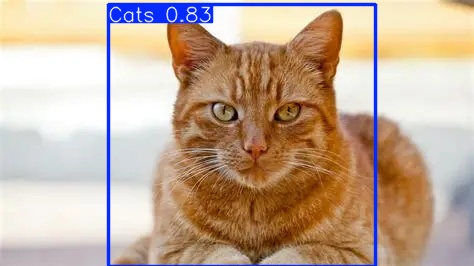

In [28]:
from IPython.display import Image, display

display(Image(filename='/content/runs/detect/predict-5/2.jpg'))

In [29]:
from ultralytics import YOLO
model = YOLO('/content/runs/detect/train/weights/best.pt')

results = model.predict(
    source='/content/4.jpg',
    conf=0.75,
    save=True
)


image 1/1 /content/4.jpg: 480x640 (no detections), 14.2ms
Speed: 6.9ms preprocess, 14.2ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-6


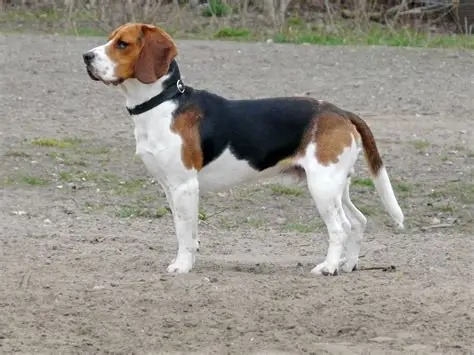

In [30]:
from IPython.display import Image, display

display(Image(filename='/content/runs/detect/predict-6/4.jpg'))

## Observations and Findings

### Key Observations
- The model successfully detects cats in most test images.
- Confidence scores vary depending on image quality and object visibility.
- The model occasionally produces false positives for visually similar animals such as dogs.

### Challenges Encountered
- Limited dataset size (43 images) reduced generalization capability.
- Small datasets increase the possibility of overfitting.
- Similar visual features between cats and dogs may lead to incorrect detections.